## Sub-Gaussian Distributional Equivalence: nu=1 and nu=3
We derive the equivalence analytically in the report. This notebook supports with simulations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import robust_ssm as ss

SEED = 0
N    = 500_000 
W    = 1.0

### Sampling from the Sub-Gaussian

In [3]:
# making sure to use different rngs for the two nu values to avoid correlations
rng1 = np.random.default_rng(SEED)
rng3 = np.random.default_rng(SEED + 1)

# SG draws
eta1 = ss.sub_gaussian_rvs(N, scale=W, nu=1.0, rng=rng1)   # nu=1
eta3 = ss.sub_gaussian_rvs(N, scale=W, nu=3.0, rng=rng3)   # nu=3

# rescale
W1 = eta1 / (W * np.sqrt(1.0))
W3 = eta3 / (W * np.sqrt(3.0))

print(f'eta1 sample support: max|eta1| = {np.abs(eta1).max():.4f}  (theoretical max = w/2 = {W/2:.4f})')
print(f'eta3 sample support: max|eta3| = {np.abs(eta3).max():.4f}  (theoretical max = w*sqrt(3)/2 = {W*np.sqrt(3)/2:.4f})')

eta1 sample support: max|eta1| = 0.5000  (theoretical max = w/2 = 0.5000)
eta3 sample support: max|eta3| = 0.8660  (theoretical max = w*sqrt(3)/2 = 0.8660)


### Histogram comparison

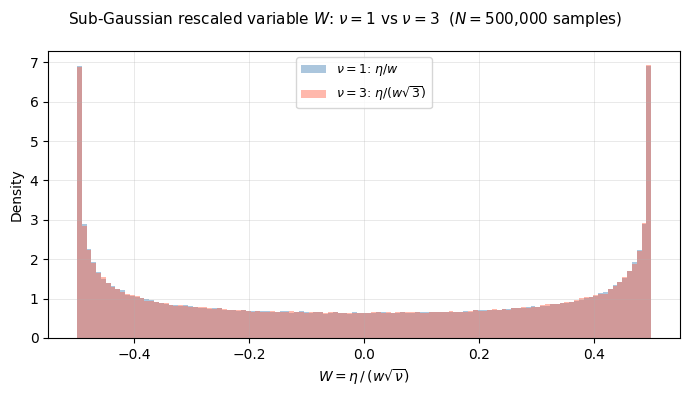

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
fig.suptitle(
    r'Sub-Gaussian rescaled variable $W$: '
    r'$\nu=1$ vs $\nu=3$  ($N=500{,}000$ samples)',
    fontsize=11,
)
bins = np.linspace(-0.5, 0.5, 120)

ax.hist(W1, bins=bins, density=True, alpha=0.45, color='steelblue',
        edgecolor='none', label=r'$\nu=1$: $\eta/w$')
ax.hist(W3, bins=bins, density=True, alpha=0.45, color='tomato',
        edgecolor='none', label=r'$\nu=3$: $\eta/(w\sqrt{3})$')
ax.set_xlabel(r'$W = \eta\,/\,(w\sqrt{\nu})$')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig('sg_shape_equivalence.png', dpi=150, bbox_inches='tight')
plt.show()

The histograms sit exactly on top of one another and match the theoretical density. Concentrated where the formula for the density of w blows up (+-0.5).

### Moment comparison

In [5]:
import pandas as pd

def moments(x, label):
    return {
        'Variable': label,
        'Mean':     round(float(np.mean(x)),     6),
        'Variance': round(float(np.var(x)),      6),
        'Skewness': round(float(stats.skew(x)),  6),
        'Kurtosis': round(float(stats.kurtosis(x)), 6),  # excess kurtosis
    }

df = pd.DataFrame([
    moments(W1, r'W1 = Z1/w       (nu=1)'),
    moments(W3, r'W3 = Z3/(w√3)  (nu=3)'),
]).set_index('Variable')

print('Moments of the rescaled sub-Gaussian W = Z/(w*sqrt(nu)):')
display(df)

Moments of the rescaled sub-Gaussian W = Z/(w*sqrt(nu)):


,Mean,Variance,Skewness,Kurtosis
Variable,,,,
W1 = Z1/w (nu=1),0.000342,0.125064,-0.001396,-1.500295
W3 = Z3/(w√3) (nu=3),0.001084,0.124838,-0.004718,-1.499134


Means both almost 0. Both fairly symmetric according to skew. Variance matches very closely. Concluding that all 4 moments match closely between the two distributions. Any differences are well within expectations for a Monte Carlo study with this N.

### KS test

A two-sample KS test under $H_0$: $W_1$ and $W_3$ are drawn from the same distribution. We expect a large p-value if the distributions are close.

In [7]:
rng_sub = np.random.default_rng(99)
idx = rng_sub.choice(N, size=10_000, replace=False)
ks_stat, ks_pval = stats.ks_2samp(W1[idx], W3[idx])
print(f'KS statistic = {ks_stat:.4f}')
print(f'p-value      = {ks_pval:.4f}')

KS statistic = 0.0155
p-value      = 0.1809
